In [1]:
!gdown --fuzzy "https://drive.google.com/file/d/1sM9_MOxz6Zp-YtMhWquK-9937znS1Dkr/view?usp=drive_link"

Downloading...
From (original): https://drive.google.com/uc?id=1sM9_MOxz6Zp-YtMhWquK-9937znS1Dkr
From (redirected): https://drive.google.com/uc?id=1sM9_MOxz6Zp-YtMhWquK-9937znS1Dkr&confirm=t&uuid=bf4b5623-f4c3-4f1b-92e9-83291638d749
To: /home/clore/dataset.tar.gz
100%|██████████████████████████████████████| 1.03G/1.03G [02:27<00:00, 7.00MB/s]


Обучение

In [ ]:
from ultralytics import YOLO
import torch

model = YOLO('yolo11m-obb.pt')

results = model.train(
    task='obb',
    data='data.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    project='lep_project_obb', 
    name='yolo11m-run1',
    device=torch.device('cuda'),
)

engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11m-run1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=lep_project_obb, rect=Fa

Сравниения нано и медиум версии 

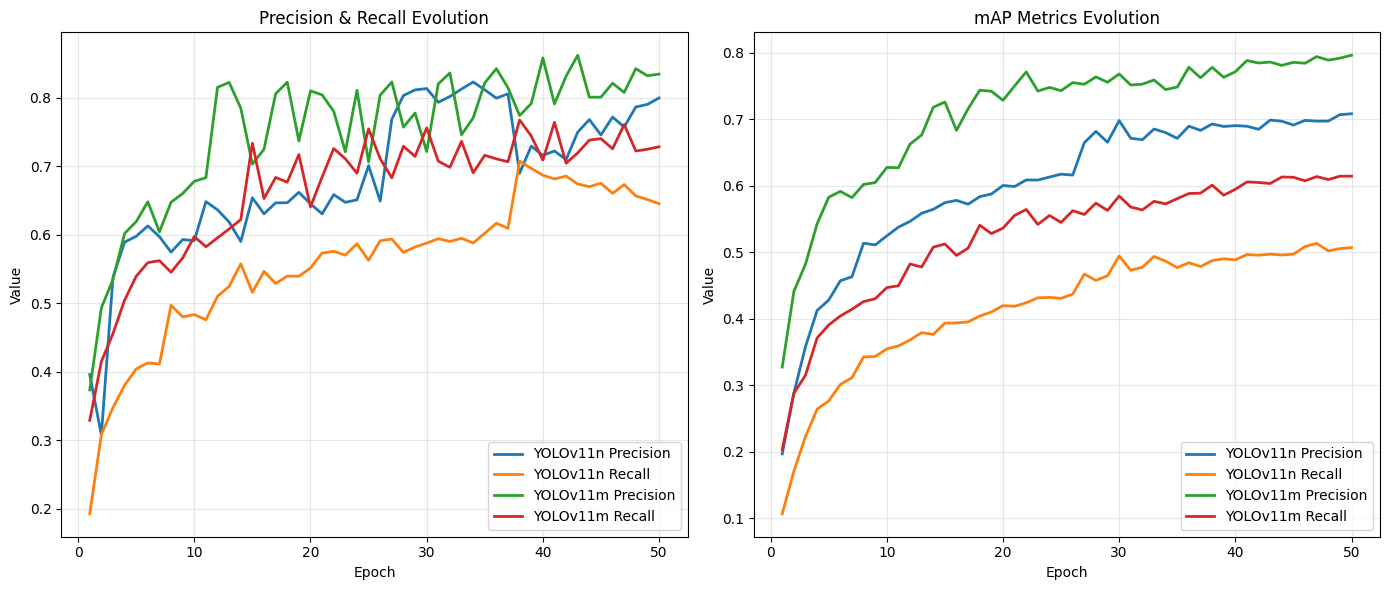

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
BASE_DIR = '/home/clore/'
df_yolo11n = pd.read_csv(BASE_DIR + 'runs/obb/lep_project_obb/yolo11n-run1/results.csv')
df_yolo11m = pd.read_csv(BASE_DIR + 'runs/obb/lep_project_obb/yolo11m-run1/results.csv')

df_yolo11n.columns = [c.strip() for c in df_yolo11n.columns]
epochs_yolo11n = df_yolo11n['epoch']
df_yolo11m.columns = [c.strip() for c in df_yolo11m.columns]
epochs_yolo11m = df_yolo11m['epoch']

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_yolo11n, df_yolo11n['metrics/precision(B)'], label='YOLOv11n Precision', lw=2)
plt.plot(epochs_yolo11n, df_yolo11n['metrics/recall(B)'], label='YOLOv11n Recall', lw=2)
plt.plot(epochs_yolo11m, df_yolo11m['metrics/precision(B)'], label='YOLOv11m Precision', lw=2)
plt.plot(epochs_yolo11m, df_yolo11m['metrics/recall(B)'], label='YOLOv11m Recall', lw=2)
plt.title('Precision & Recall Evolution')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_yolo11n, df_yolo11n['metrics/mAP50(B)'], label='YOLOv11n Precision', lw=2)
plt.plot(epochs_yolo11n, df_yolo11n['metrics/mAP50-95(B)'], label='YOLOv11n Recall', lw=2)
plt.plot(epochs_yolo11m, df_yolo11m['metrics/mAP50(B)'], label='YOLOv11m Precision', lw=2)
plt.plot(epochs_yolo11m, df_yolo11m['metrics/mAP50-95(B)'], label='YOLOv11m Recall', lw=2)
plt.title('mAP Metrics Evolution')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
def print_result(metrics, name_model):
    print("\n" + "="*30)
    print(f'ФИНАЛЬНЫЕ МЕТРИКИ ({name_model})')
    print("="*30)
    print(f"Precision: {metrics.box.mp:.4f}")
    print(f"Recall:    {metrics.box.mr:.4f}")
    print(f"mAP@50:    {metrics.box.map50:.4f}")
    print(f"mAP@50-95: {metrics.box.map:.4f}")
    print("="*30)

In [13]:
from ultralytics import YOLO

model_yolo11n = YOLO(BASE_DIR + 'runs/obb/lep_project_obb/yolo11n-run1/weights/best.pt')
model_yolo11m = YOLO(BASE_DIR + 'runs/obb/lep_project_obb/yolo11m-run1/weights/best.pt')

metrics_yolo11n = model_yolo11n.val(data='data.yaml', split='test')
metrics_yolo11m = model_yolo11m.val(data='data.yaml', split='test')

Ultralytics 8.4.13 🚀 Python-3.8.10 torch-2.0.1+cu117 CUDA:0 (NVIDIA GeForce RTX 4090, 24210MiB)
YOLO11n-obb summary (fused): 110 layers, 2,655,283 parameters, 0 gradients, 6.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6481.2±4134.7 MB/s, size: 577.0 KB)
val: Scanning /home/clore/dataset/test/labels... 766 images, 1 backgrounds, 41 corrupt: 100% ━━━━━━━━━━━━ 766/766 2.8Kit/s 0.3s0.1ss
val: /home/clore/dataset/test/images/110_bd-20-_jpg.rf.e139605b864c24800f23308fa70613b5.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.2004]
val: /home/clore/dataset/test/images/110_bd-56-_jpg.rf.ca8ccdb78a331786fd506be255eadc1b.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0571]
val: /home/clore/dataset/test/images/110_dl-58-_jpg.rf.e5d6390718c1398cfaf6db5ffb78aa69.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0458      1.0265]
val: /home/clore/dataset/test/images/110_kh

Общие результаты

In [14]:
print_result(metrics_yolo11n, 'YOLOv11n')
print_result(metrics_yolo11m, 'YOLOv11m')


ФИНАЛЬНЫЕ МЕТРИКИ (YOLOv11n)
Precision: 0.7581
Recall:    0.6555
mAP@50:    0.6977
mAP@50-95: 0.5043

ФИНАЛЬНЫЕ МЕТРИКИ (YOLOv11m)
Precision: 0.8527
Recall:    0.7816
mAP@50:    0.8356
mAP@50-95: 0.6258


Результаты по классам

In [16]:
print(f"{'-'*10}YOLOv11n{'-'*10}")
for i, name in enumerate(metrics_yolo11n.names.values()):
    print(f'Class {name}: {metrics_yolo11n.box.maps[i]:.3f}')
print(f"{'-'*10}YOLOv11m{'-'*10}")
for i, name in enumerate(metrics_yolo11m.names.values()):
    print(f'Class {name}: {metrics_yolo11m.box.maps[i]:.3f}')

----------YOLOv11n----------
Class vibration_damper: 0.447
Class festoon_insulators: 0.724
Class polymer_insulators: 0.719
Class traverse: 0.162
Class nest: 0.365
Class bad_insulator: 0.757
Class damaged_insulator: 0.763
Class safety_sign: 0.096
----------YOLOv11m----------
Class vibration_damper: 0.538
Class festoon_insulators: 0.787
Class polymer_insulators: 0.799
Class traverse: 0.530
Class nest: 0.468
Class bad_insulator: 0.860
Class damaged_insulator: 0.901
Class safety_sign: 0.123
